In [ ]:
from google.colab import files
uploaded = files.upload()  # CSV-Datei auswählen

Shape: (9994, 21)

Spalten: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Erste Zeilen:

Fehlende Werte:
 Series([], dtype: int64)


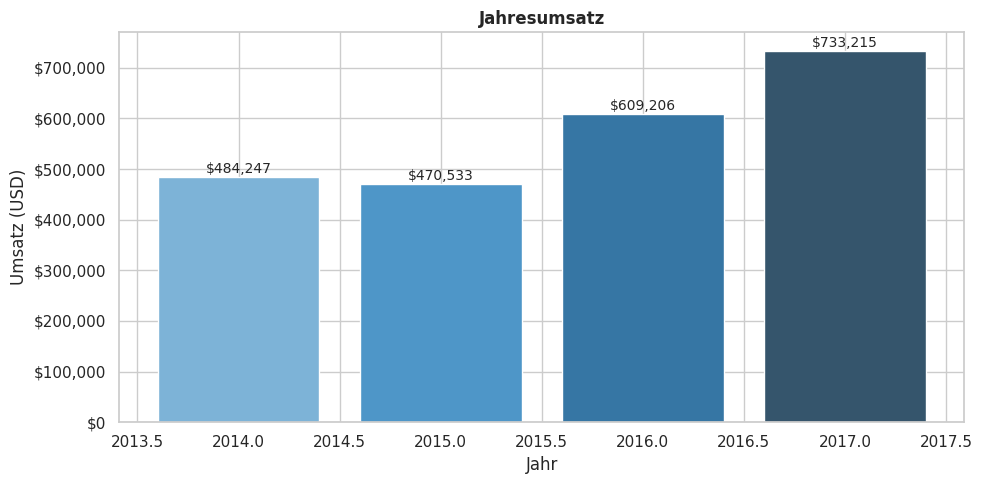

 Bestes Jahr: 2017 mit $733,215


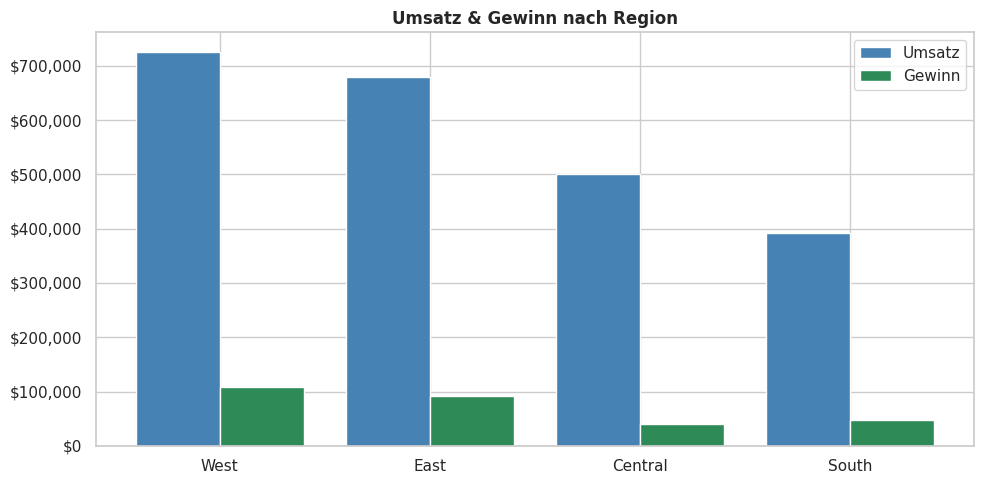

 Beste Region: West


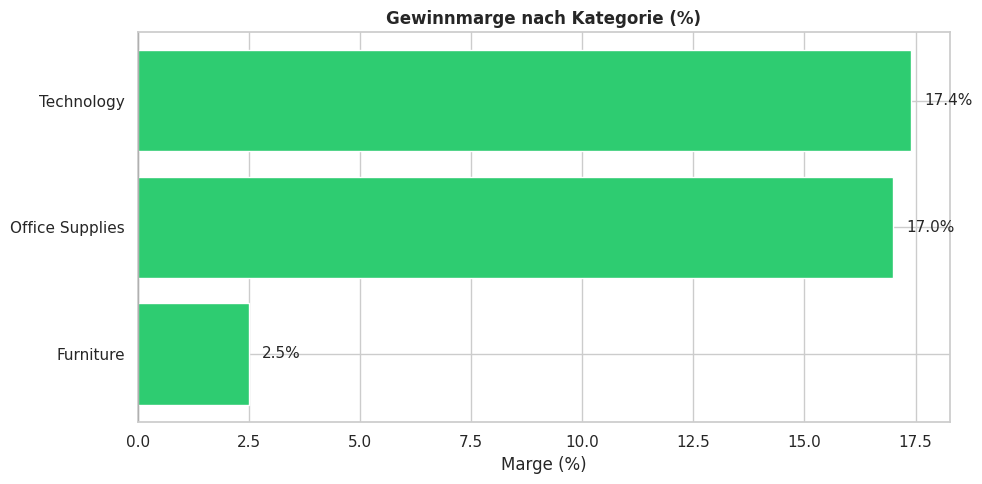

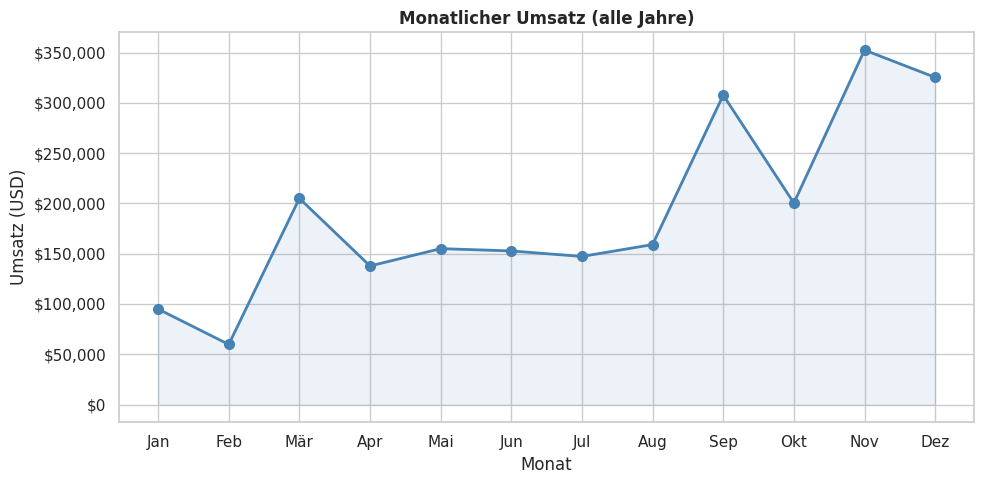

 Stärkster Monat: Nov

 ZUSAMMENFASSUNG
Gesamtumsatz:    $   2,297,201
Gesamtgewinn:    $     286,397
Gesamte Orders:         5,009
Ø Gewinnmarge:          12.0%
Beste Kategorie:   Technology
Beste Region:            West


In [8]:
# Superstore Sales Analysis

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Stil festlegen
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

#  1. DATEN LADEN
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

print("Shape:", df.shape)
print("\nSpalten:", df.columns.tolist())
print("\nErste Zeilen:")
df.head()

#  2. DATEN BEREINIGEN
# Datum konvertieren
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Neue Spalten
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Profit Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)

# Fehlende Werte prüfen
print("\nFehlende Werte:\n", df.isnull().sum()[df.isnull().sum() > 0])

#  3. FRAGE 1: Welches Jahr hatte den höchsten Umsatz?
yearly = df.groupby('Year')['Sales'].sum().reset_index()

fig, ax = plt.subplots()
bars = ax.bar(yearly['Year'], yearly['Sales'], color=sns.color_palette("Blues_d", len(yearly)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Jahresumsatz', fontweight='bold')
ax.set_xlabel('Jahr')
ax.set_ylabel('Umsatz (USD)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('yearly_sales.png', dpi=150)
plt.show()
print(f" Bestes Jahr: {yearly.loc[yearly['Sales'].idxmax(), 'Year']} "
      f"mit ${yearly['Sales'].max():,.0f}")

#  4. FRAGE 2: Welche Region performt am besten?
region = df.groupby('Region')[['Sales','Profit']].sum().reset_index()
region = region.sort_values('Sales', ascending=False)

fig, ax = plt.subplots()
x = range(len(region))
width = 0.4
ax.bar([i - width/2 for i in x], region['Sales'],  width=width, label='Umsatz',  color='steelblue')
ax.bar([i + width/2 for i in x], region['Profit'], width=width, label='Gewinn', color='seagreen')
ax.set_xticks(list(x))
ax.set_xticklabels(region['Region'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Umsatz & Gewinn nach Region', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('region_sales.png', dpi=150)
plt.show()
print(f" Beste Region: {region.iloc[0]['Region']}")

#  5. FRAGE 3: Welche Produktkategorie ist am profitabelsten?
cat = df.groupby('Category')[['Sales','Profit']].sum().reset_index()
cat['Margin %'] = (cat['Profit'] / cat['Sales'] * 100).round(1)

fig, ax = plt.subplots()
colors = ['#e74c3c' if m < 0 else '#2ecc71' for m in cat['Margin %']]
bars = ax.barh(cat['Category'], cat['Margin %'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Gewinnmarge nach Kategorie (%)', fontweight='bold')
ax.set_xlabel('Marge (%)')
for bar, val in zip(bars, cat['Margin %']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('category_margin.png', dpi=150)
plt.show()

# ── 6. FRAGE 4: Welcher Monat hat den höchsten Umsatz? ──
monthly = df.groupby('Month')['Sales'].sum().reset_index()
month_names = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']
monthly['Month Name'] = monthly['Month'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots()
ax.plot(monthly['Month Name'], monthly['Sales'], marker='o',
        color='steelblue', linewidth=2, markersize=7)
ax.fill_between(range(len(monthly)), monthly['Sales'], alpha=0.1, color='steelblue')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['Month Name'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Monatlicher Umsatz (alle Jahre)', fontweight='bold')
ax.set_xlabel('Monat')
ax.set_ylabel('Umsatz (USD)')
plt.tight_layout()
plt.savefig('monthly_sales.png', dpi=150)
plt.show()
best_month = monthly.loc[monthly['Sales'].idxmax(), 'Month Name']
print(f" Stärkster Monat: {best_month}")

#  7. ZUSAMMENFASSUNG
print("\n" + "="*45)
print(" ZUSAMMENFASSUNG")
print("="*45)
print(f"Gesamtumsatz:    ${df['Sales'].sum():>12,.0f}")
print(f"Gesamtgewinn:    ${df['Profit'].sum():>12,.0f}")
print(f"Gesamte Orders:  {df['Order ID'].nunique():>12,}")
print(f"Ø Gewinnmarge:   {df['Profit Margin'].mean():>11.1f}%")
print(f"Beste Kategorie: {cat.loc[cat['Margin %'].idxmax(), 'Category']:>12}")
print(f"Beste Region:    {region.iloc[0]['Region']:>12}")
print("="*45)